# Mangan

V datoteki `Mangan.csv` so podatki o deležu mangana v železu, pridobljenem v plavžu: skozi 24 dni so vsak dan analizirali pet odlitkov.

In [48]:
%matplotlib inline

import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

mangan = pd.read_csv("../data/Mangan.csv",index_col="DAN")
values = mangan.to_numpy().ravel()
values = np.sort(values)

n = len(values)
MIN = min(values)
MAX = max(values)
mu = values.mean()
sigma = values.std(ddof=1)

Preučite normalnost dobljene empirične porazdelitve, tako da narišete:

- histogram z dorisano ustrezno normalno gostoto;
- viseči histogram razlik korenov frekvenc: glejte razdelek 9.7 v knjigi;
- primerjalni kvantilni ($Q$-$Q$) grafikon: glejte razdelek 9.8 v knjigi.

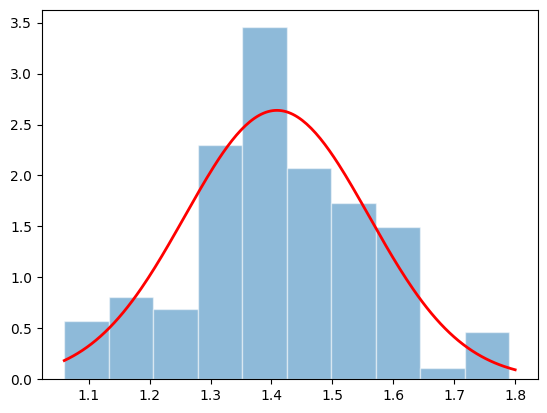

In [50]:
IQR = np.percentile(values, 75) - np.percentile(values, 25)  # interquantile range
FD = 2 * IQR / np.power(n, 1 / 3)  # Freedman-Diaconis rule

plt.hist(
    values, bins=np.arange(MIN, MAX, FD), density=True, alpha=0.5, edgecolor="white"
)

x = np.linspace(MIN, MAX, 200)
plt.plot(x, norm.pdf(x, mu, sigma), "r", linewidth=2)

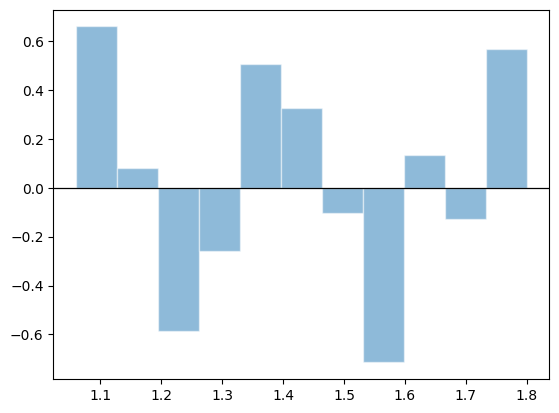

In [42]:
counts, edges = np.histogram(values, bins=11)
centers = (edges[:-1] + edges[1:]) / 2
width = edges[1] - edges[0]

expected = np.array(
    [
        n * (norm.cdf(edges[i + 1], mu, sigma) - norm.cdf(edges[i], mu, sigma))
        for i in range(len(edges) - 1)
    ]
)

residuals = np.sqrt(counts) - np.sqrt(expected)

plt.axhline(0, color="black", linewidth=0.9, zorder=4)
plt.bar(centers, residuals, width=width, edgecolor="white", alpha=0.5)

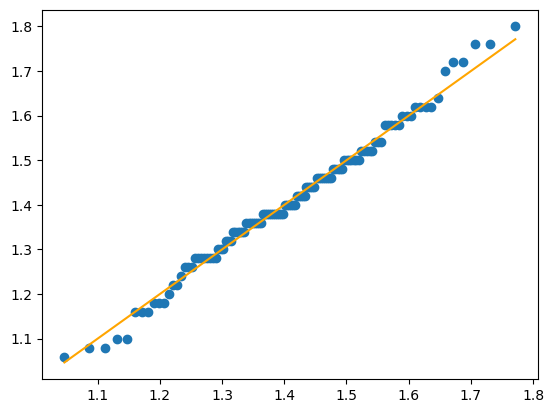

In [52]:
p = np.linspace(1 / (n + 1), n / (n + 1), n)
pp = norm.ppf(p, loc=mu, scale=sigma)

plt.scatter(pp, values)

plt.plot(
    [norm.ppf(p, loc=mu, scale=sigma) for p in [1 / (n + 1), n / (n + 1)]],
    [norm.ppf(p, mu, sigma) for p in [1 / (n + 1), n / (n + 1)]],
    color="orange",
)